In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
import xgboost
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

#### Loading Dataset

In [2]:
ls

catboost_info/
client_project_sales_representative.ipynb
PRCL 0019 [SLAES]-Copy1.ipynb
PRCL-0019.pdf
preprocess_data_sales_prcl_0019.csv
project_sales.csv
Untitled-2.csv


In [3]:
data = pd.read_csv('Untitled-2.csv')
display(data.head(5))
display(data.tail(5))

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25.0,Website,NaN,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Created        7422 non-null   object 
 1   Product_ID     7364 non-null   float64
 2   Source         7405 non-null   object 
 3   Mobile         5612 non-null   object 
 4   EMAIL          7422 non-null   object 
 5   Sales_Agent    7399 non-null   object 
 6   Location       7364 non-null   object 
 7   Delivery_Mode  7422 non-null   object 
 8   Status         7422 non-null   object 
dtypes: float64(1), object(8)
memory usage: 522.0+ KB


In [5]:
data.describe()

,Product_ID
count,7364.000000
mean,15.947311
std,6.072937
min,0.000000
25%,12.000000
50%,18.000000
75%,19.000000
max,28.000000


#### EDA

Product ID

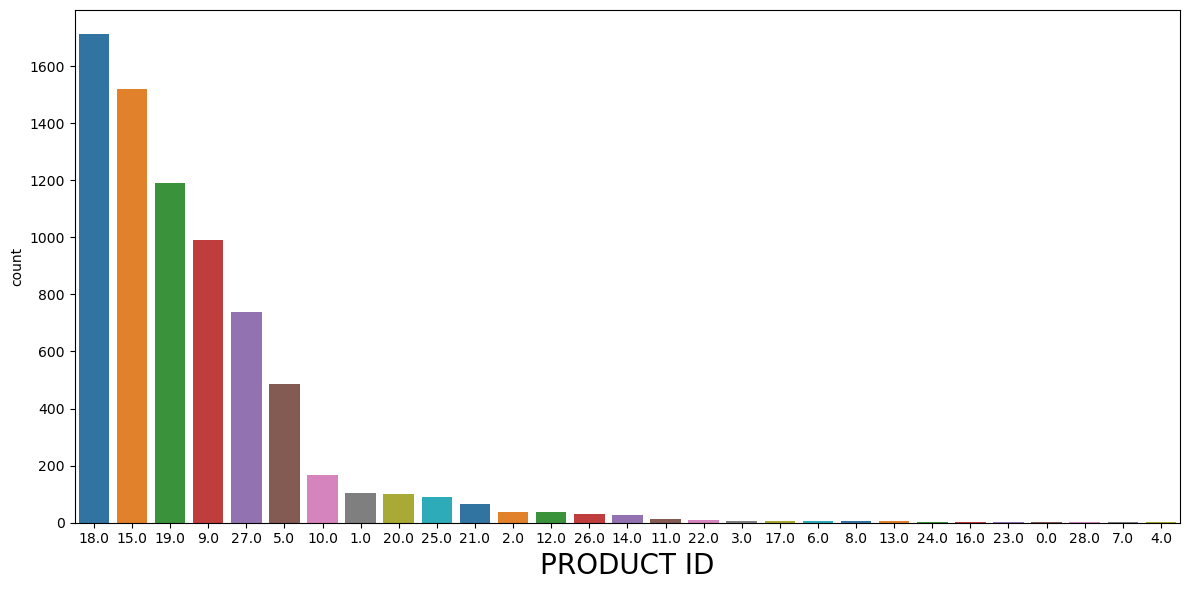

In [6]:
plt.figure(figsize = (12,6))
order = data['Product_ID'].value_counts().sort_values(ascending= False).index

sns.countplot(data = data, x = 'Product_ID', order = order ,palette='tab10')


plt.xlabel('PRODUCT ID', fontsize = 20)
plt.tight_layout()
plt.show()

Source

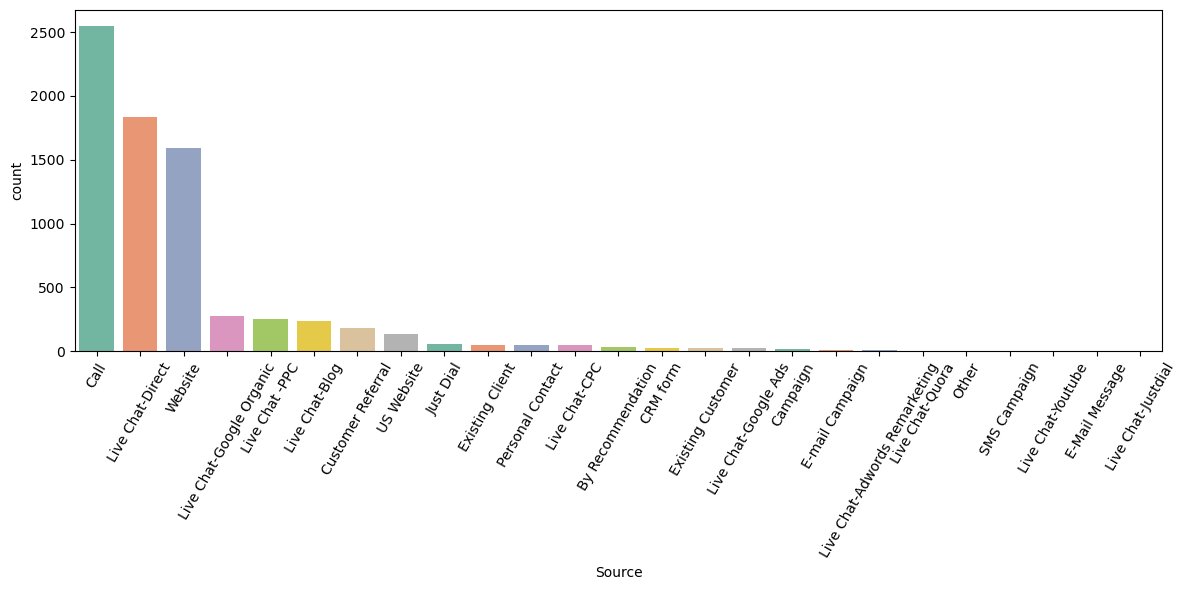

In [7]:
plt.figure(figsize = (12,6))
order = data['Source'].value_counts().sort_values(ascending= False).index

sns.countplot(data = data, x = 'Source', order = order , palette='Set2')


plt.xlabel('Source')
plt.xticks(rotation = 60)
plt.tight_layout()
plt.show()

Sales Agent

In [8]:
print(data['Sales_Agent'].unique())

['Sales-Agent-11' 'Sales-Agent-10' 'Sales-Agent-3' 'Sales-Agent-4'
 'Sales-Agent-9' 'Sales-Agent-7' nan 'Sales-Agent-8' 'Sales-Agent-5'
 'Sales-Agent-2' 'Sales-Agent-12' 'Sales-Agent-1' 'Sales-Agent-6']


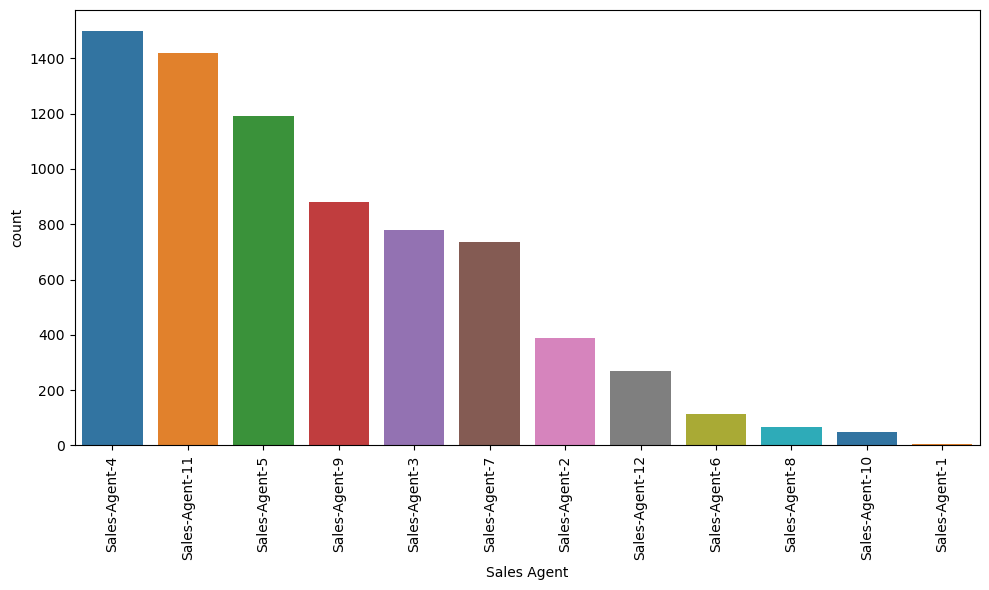

In [9]:
plt.figure(figsize=(10, 6))

order = data['Sales_Agent'].value_counts().sort_values(ascending=False).index

sns.countplot( data=data, x='Sales_Agent' , order = order,palette='tab10')

plt.xlabel('Sales Agent')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()


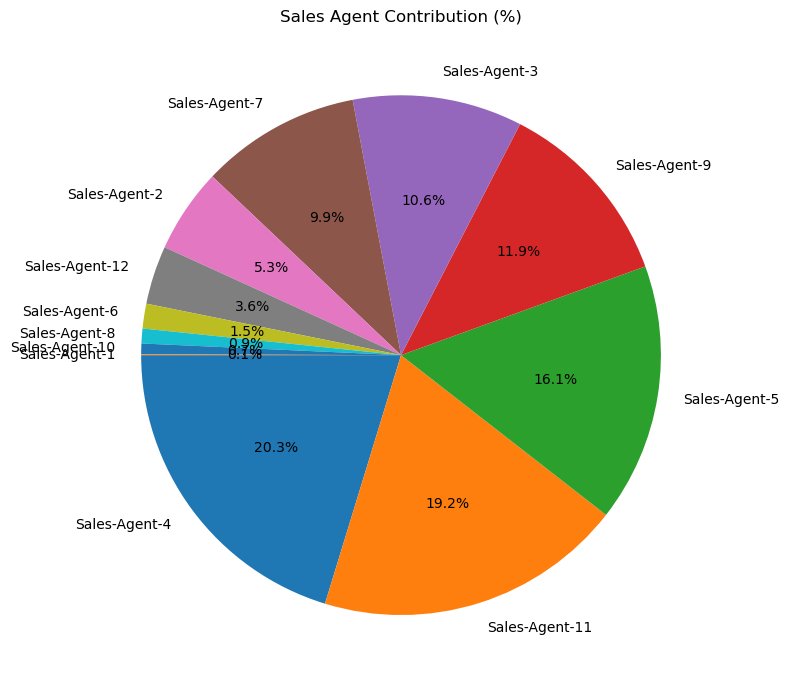

In [10]:
agent_counts = data['Sales_Agent'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    agent_counts,
    labels=agent_counts.index,
    autopct='%1.1f%%',
    startangle=180
)
plt.title('Sales Agent Contribution (%)')
plt.tight_layout()
plt.show()


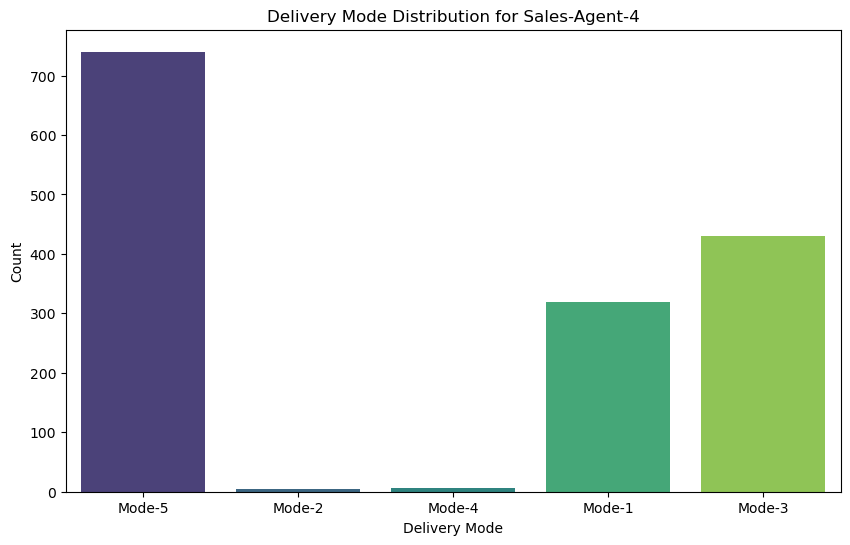

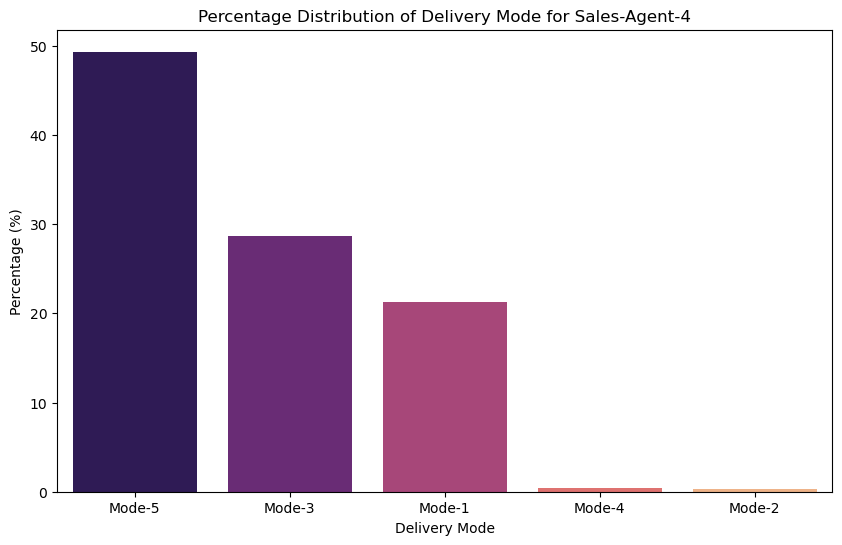

In [11]:
salesagent4 = data[data['Sales_Agent'] == 'Sales-Agent-4']


plt.figure(figsize=(10, 6))
sns.countplot(data=salesagent4, x='Delivery_Mode', palette='viridis')

plt.title('Delivery Mode Distribution for Sales-Agent-4')
plt.xlabel('Delivery Mode')
plt.ylabel('Count')
plt.show()


plt.figure(figsize=(10, 6))
delivery_pct = salesagent4['Delivery_Mode'].value_counts(normalize=True) * 100
sns.barplot(x=delivery_pct.index, y=delivery_pct.values, palette='magma')

plt.title('Percentage Distribution of Delivery Mode for Sales-Agent-4')
plt.xlabel('Delivery Mode')
plt.ylabel('Percentage (%)')
plt.show()

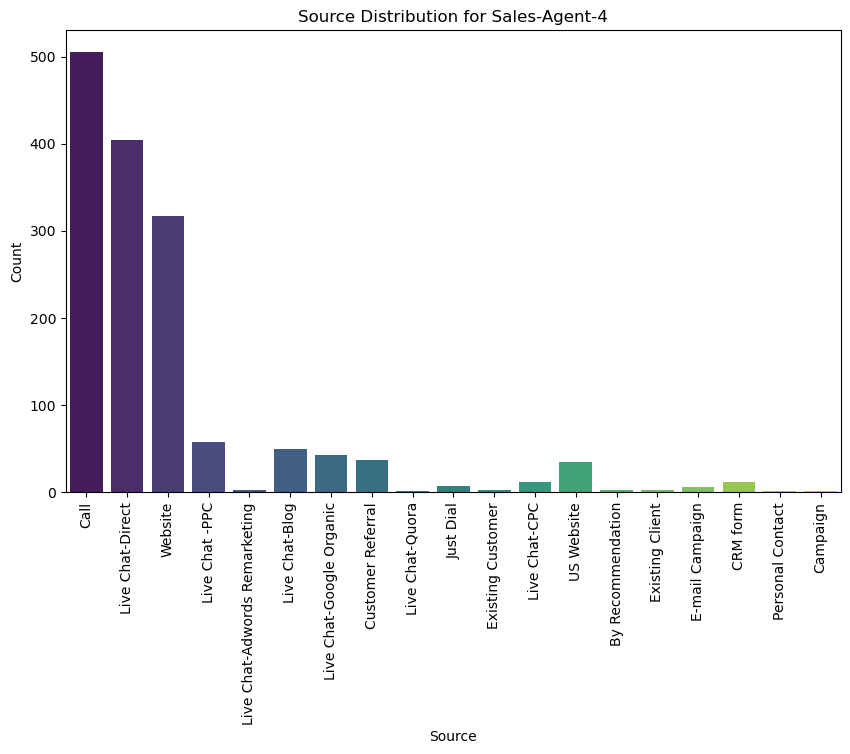

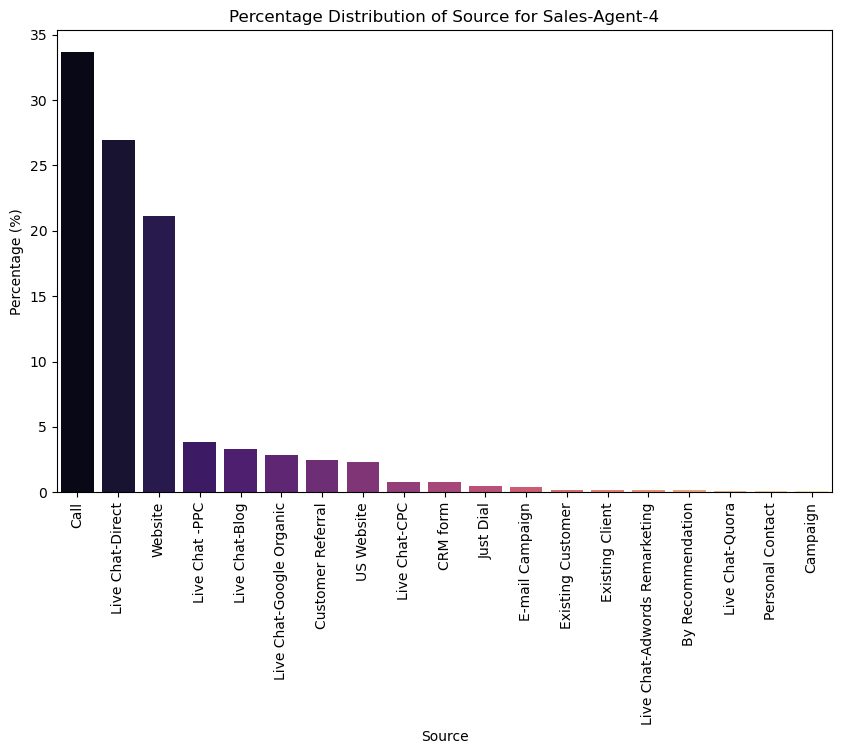

In [12]:
salesagent4 = data[data['Sales_Agent'] == 'Sales-Agent-4']


plt.figure(figsize=(10, 6))
sns.countplot(data=salesagent4, x='Source', palette='viridis')

plt.title('Source Distribution for Sales-Agent-4')
plt.xlabel('Source')
plt.xticks(rotation = 90)
plt.ylabel('Count')
plt.show()


plt.figure(figsize=(10, 6))
delivery_pct = salesagent4['Source'].value_counts(normalize=True) * 100
sns.barplot(x=delivery_pct.index, y=delivery_pct.values, palette='magma')

plt.title('Percentage Distribution of Source for Sales-Agent-4')
plt.xlabel('Source')
plt.xticks(rotation = 90)

plt.ylabel('Percentage (%)')
plt.show()

Location

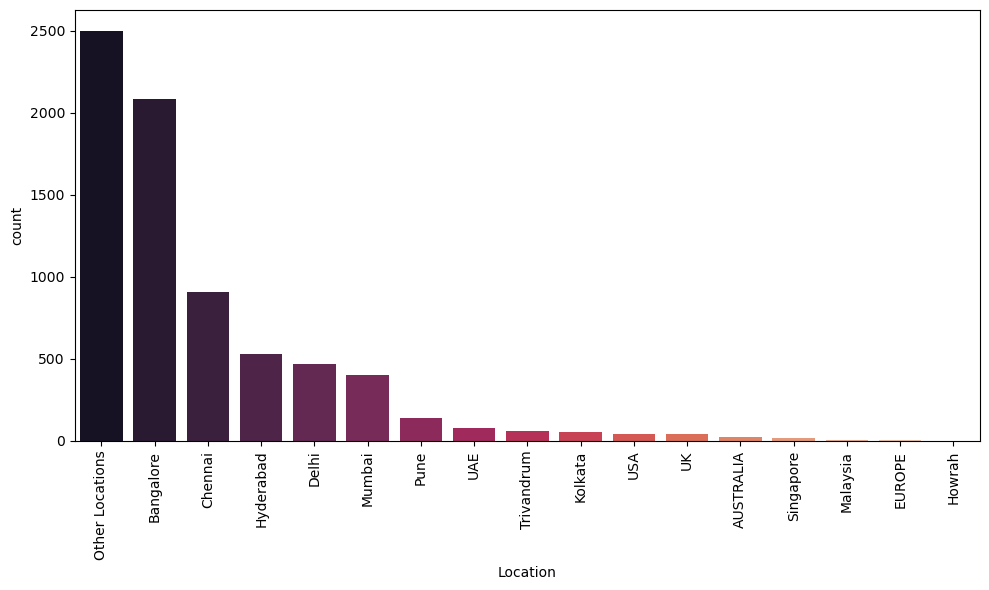

In [13]:
plt.figure(figsize=(10, 6))

order = data['Location'].value_counts().sort_values(ascending=False).index

sns.countplot( data=data, x='Location' , order = order,palette='rocket')

plt.xlabel('Location')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()


Delivery Mode

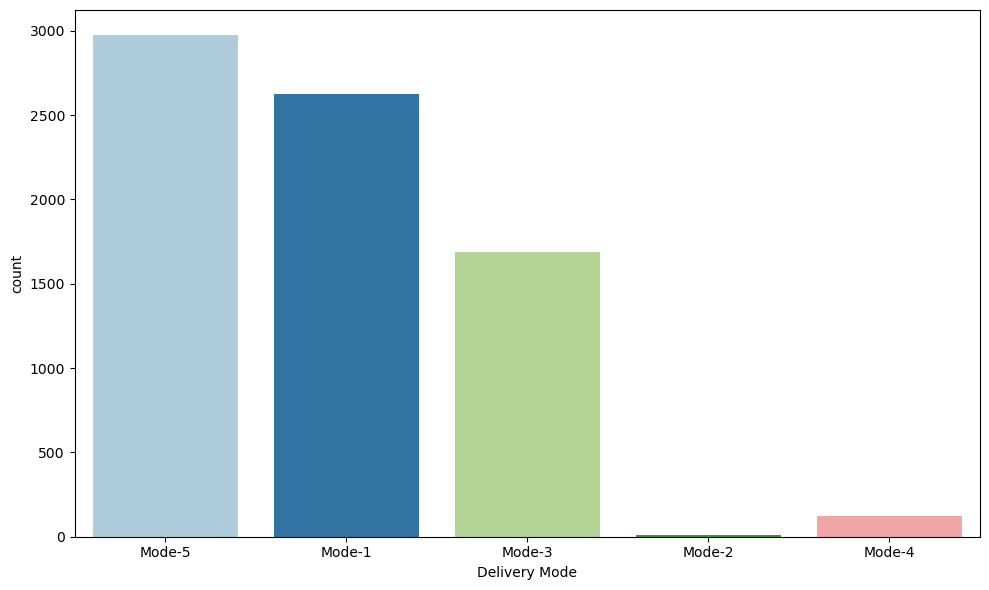

In [14]:
plt.figure(figsize=(10, 6))

sns.countplot( data=data, x='Delivery_Mode' ,palette='Paired')

plt.xlabel('Delivery Mode')
# plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()


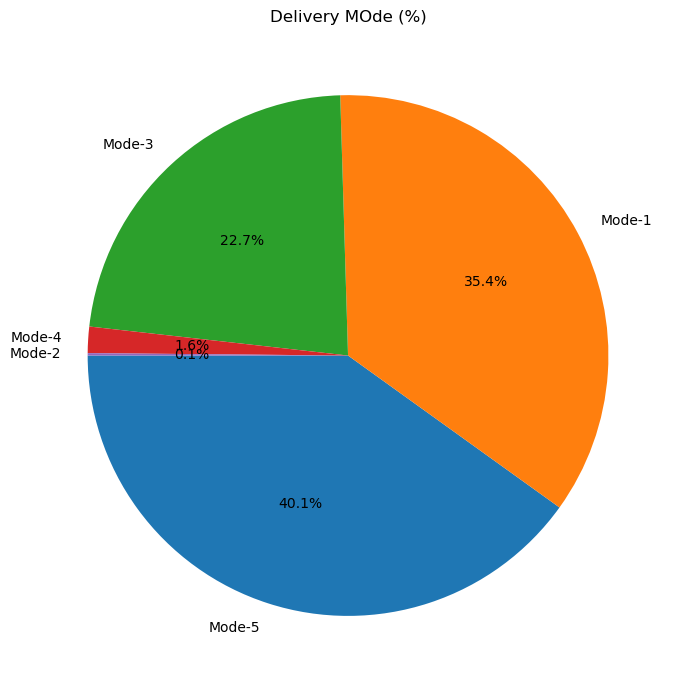

In [15]:
mode_counts = data['Delivery_Mode'].value_counts()

plt.figure(figsize=(7, 8))
plt.pie(
    mode_counts,
    labels=mode_counts.index,
    autopct='%1.1f%%',
    startangle=180
)
plt.title('Delivery MOde (%)')
plt.tight_layout()
plt.show()


Status

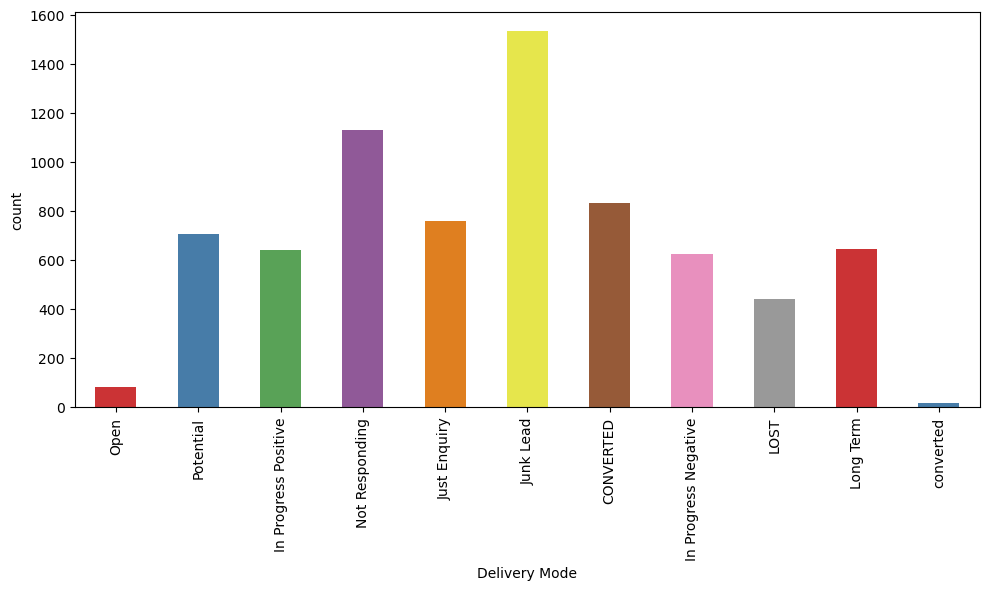

In [16]:
plt.figure(figsize=(10, 6))

sns.countplot( data=data, x='Status' ,palette='Set1', width=0.5)

plt.xlabel('Delivery Mode')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()


### Data Preprocessing / Feature Engineering

Checking missing value

In [17]:
data.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


In [18]:
#checking null value or NaN

data.isnull().sum()

Created             0
Product_ID         58
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           58
Delivery_Mode       0
Status              0
dtype: int64

In [19]:
data['Product_ID'].mode()

0    18.0
Name: Product_ID, dtype: float64

In [20]:
data['Product_ID'] = data['Product_ID'].fillna(data['Product_ID'].mode()[0])

data.isnull().sum()

Created             0
Product_ID          0
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           58
Delivery_Mode       0
Status              0
dtype: int64

In [21]:
data['Source'] = data['Source'].fillna(data['Source'].mode()[0])

data['Sales_Agent'] = data['Sales_Agent'].fillna(data['Sales_Agent'].mode()[0])

data['Location'] = data['Location'].fillna(data['Location'].mode()[0])

In [22]:
data.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,18.0,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,Other Locations,Mode-5,Open
1,14-11-2018 09:22,18.0,Website,XXXXXXX,#VALUE!,Sales-Agent-10,Other Locations,Mode-5,Open
2,14-11-2018 09:21,18.0,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,Other Locations,Mode-5,Open
3,14-11-2018 08:46,18.0,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,Other Locations,Mode-5,Open
4,14-11-2018 07:34,18.0,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,Other Locations,Mode-5,Open


In [23]:
data['EMAIL'] = data['EMAIL'].replace('#VALUE!', 'awsxxxxxxx@gmail.com')
data.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,18.0,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,Other Locations,Mode-5,Open
1,14-11-2018 09:22,18.0,Website,XXXXXXX,awsxxxxxxx@gmail.com,Sales-Agent-10,Other Locations,Mode-5,Open
2,14-11-2018 09:21,18.0,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,Other Locations,Mode-5,Open
3,14-11-2018 08:46,18.0,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,Other Locations,Mode-5,Open
4,14-11-2018 07:34,18.0,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,Other Locations,Mode-5,Open


In [24]:
data.isnull().sum()

Created             0
Product_ID          0
Source              0
Mobile           1810
EMAIL               0
Sales_Agent         0
Location            0
Delivery_Mode       0
Status              0
dtype: int64

Product ID

In [25]:
data['Product_ID'] = pd.to_numeric(data['Product_ID'], errors='coerce')


data['Product_ID'] = data['Product_ID'].replace([11, 22, 3, 17, 6, 8, 13, 24, 16, 23, 0, 28, 7, 4], 'minimum sold')



In [26]:
data.Product_ID.unique()

array([18.0, 9.0, 19.0, 15.0, 27.0, 5.0, 2.0, 'minimum sold', 25.0, 10.0,
       20.0, 21.0, 1.0, 12.0, 26.0, 14.0], dtype=object)

In [27]:
print(data['Product_ID'].value_counts()['minimum sold'])

65


Source

In [28]:
data.Source.unique()

array(['Website', 'Call', 'Live Chat-Google Organic', 'Live Chat-Direct',
       'By Recommendation', 'Customer Referral', 'Live Chat-Blog',
       'Live Chat -PPC', 'Live Chat-Google Ads',
       'Live Chat-Adwords Remarketing', 'E-Mail Message',
       'Existing Client', 'Live Chat-CPC', 'Existing Customer',
       'Live Chat-Quora', 'US Website', 'Just Dial', 'Campaign', 'Other',
       'E-mail Campaign', 'CRM form', 'SMS Campaign', 'Personal Contact',
       'Live Chat-Youtube', 'Live Chat-Justdial'], dtype=object)

 converting unwanted label into simple 'Live Chat'

In [29]:
data.Source.replace([
    'Live Chat-Google Organic', 'Live Chat-Direct', 'Live Chat-Blog', 'Live Chat -PPC',
    'Live Chat-Google Ads', 'Live Chat-Adwords Remarketing', 'Live Chat-CPC',
    'Live Chat-Quora', 'Live Chat-Youtube', 'Live Chat-Justdial'
],    'live chat',inplace=True)

converting unwanted label into simple 'new client'

In [30]:
data.Source.replace([
    'Existing Client','Personal Contact','CRM form','Existing Customer'
],'new client',inplace=True)

In [31]:
data.Source.replace([
    'Customer Referral','By Recommendation'
],'recommendation',inplace=True)

In [32]:
data.Source.replace([
    'Campaign','E-mail Campaign','SMS Campaign','E-Mail Message'
],'campaign',inplace=True)

In [33]:
data.Source.replace(['US Website','Just Dial'],'social',inplace=True)

In [34]:
data['Source'].value_counts()

Source
live chat         2677
Call              2564
Website           1594
recommendation     212
social             193
new client         146
campaign            34
Other                2
Name: count, dtype: int64

Location

In [35]:
data['Location'].value_counts()

Location
Other Locations    2558
Bangalore          2084
Chennai             909
Hyderabad           528
Delhi               471
Mumbai              402
Pune                142
UAE                  79
Trivandrum           58
Kolkata              55
USA                  45
UK                   41
AUSTRALIA            25
Singapore            17
Malaysia              4
EUROPE                3
Howrah                1
Name: count, dtype: int64

Kolkata Howrah Malaysia UAE has appeared less so merging to prevent from overfitting

and UAE USA UK Australia Singapore Europe are merge into International 

In [36]:
data['Location'].replace(['Trivandrum','Kolkata','Howrah'],'Other Locations',inplace=True)



international_list = ['UAE', 'USA', 'UK', 'AUSTRALIA', 'Singapore', 'Malaysia', 'EUROPE']
data['Location'].replace(international_list, 'International', inplace=True)



In [37]:
data['Location'].value_counts()

Location
Other Locations    2672
Bangalore          2084
Chennai             909
Hyderabad           528
Delhi               471
Mumbai              402
International       214
Pune                142
Name: count, dtype: int64

Status


In [38]:
data['Status'].unique()

array(['Open', 'Potential', 'In Progress Positive', 'Not Responding',
       'Just Enquiry', 'Junk Lead', 'CONVERTED', 'In Progress Negative',
       'LOST', 'Long Term', 'converted'], dtype=object)

Status is the Target variable, so the 11 label in sales are merge into two groups : 
HIGH POTENTIAL and LOW POTENTIAL GROUPING.


In [39]:
data['Status'].value_counts()

Status
Junk Lead               1536
Not Responding          1129
CONVERTED                834
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      82
converted                 18
Name: count, dtype: int64

In [40]:
data.Status[data['Status']=='Junk Lead']=0
data.Status[data['Status']=='Not Responding']=0
data.Status[data['Status']=='CONVERTED']=1
data.Status[data['Status']=='Just Enquiry']=1
data.Status[data['Status']=='Potential']=1
data.Status[data['Status']=='Long Term']=1
data.Status[data['Status']=='In Progress Positive']=1
data.Status[data['Status']=='In Progress Negative']=0
data.Status[data['Status']=='LOST']=0
data.Status[data['Status']=='Open']=1
data.Status[data['Status']=='converted']=1

In [41]:
data['Status'].value_counts()

Status
0    3731
1    3691
Name: count, dtype: int64

#### Categorical Data Conversion

In [42]:
data.loc[data['Product_ID']=='minimum sold','Product_ID']=0

In [43]:
from sklearn.preprocessing import LabelEncoder               #Label Encoding
enc=LabelEncoder()
data.Source=enc.fit_transform(data.Source)
data.Sales_Agent=enc.fit_transform(data.Sales_Agent)
data.Location=enc.fit_transform(data.Location)
data.Delivery_Mode=enc.fit_transform(data.Delivery_Mode)

In [44]:
data.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,18.0,2,984XXXXXXX,aXXXXXXX@gmail.com,2,6,4,1
1,14-11-2018 09:22,18.0,2,XXXXXXX,awsxxxxxxx@gmail.com,1,6,4,1
2,14-11-2018 09:21,18.0,2,XXXXXXX,dXXXXXXX@yahoo.com,1,6,4,1
3,14-11-2018 08:46,18.0,2,XXXXXXX,wXXXXXXX@gmail.com,1,6,4,1
4,14-11-2018 07:34,18.0,2,XXXXXXX,cXXXXXXX@gmail.com,1,6,4,1


In [45]:
data.drop(columns=['Created','Mobile','EMAIL'], inplace= True)

In [46]:
data.head()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
0,18.0,2,2,6,4,1
1,18.0,2,1,6,4,1
2,18.0,2,1,6,4,1
3,18.0,2,1,6,4,1
4,18.0,2,1,6,4,1


In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product_ID     7422 non-null   object
 1   Source         7422 non-null   int64 
 2   Sales_Agent    7422 non-null   int64 
 3   Location       7422 non-null   int64 
 4   Delivery_Mode  7422 non-null   int64 
 5   Status         7422 non-null   object
dtypes: int64(4), object(2)
memory usage: 348.0+ KB


In [48]:
data['Product_ID']=data['Product_ID'].astype('int64')
data['Status']=data['Status'].astype('int64')

<Axes: >

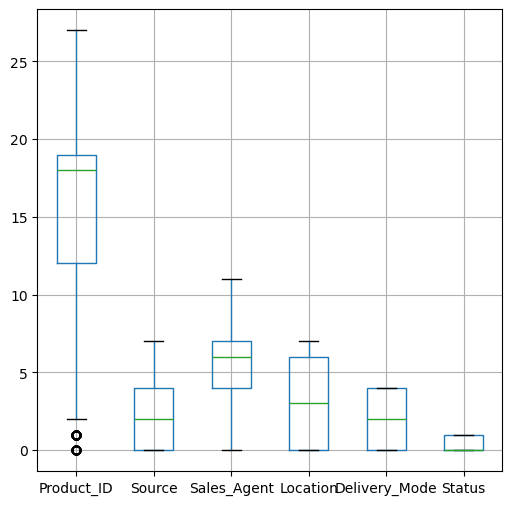

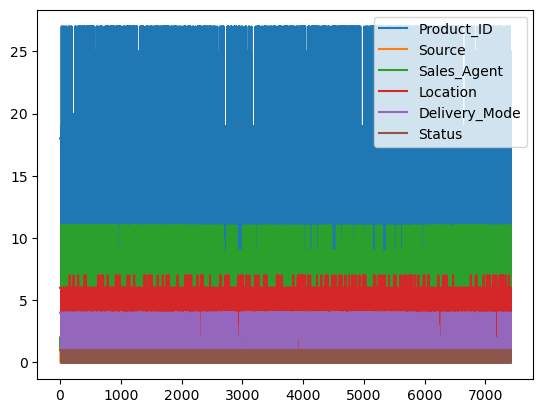

In [49]:
data.boxplot(figsize=(6,6))
data.plot()

### Correlation

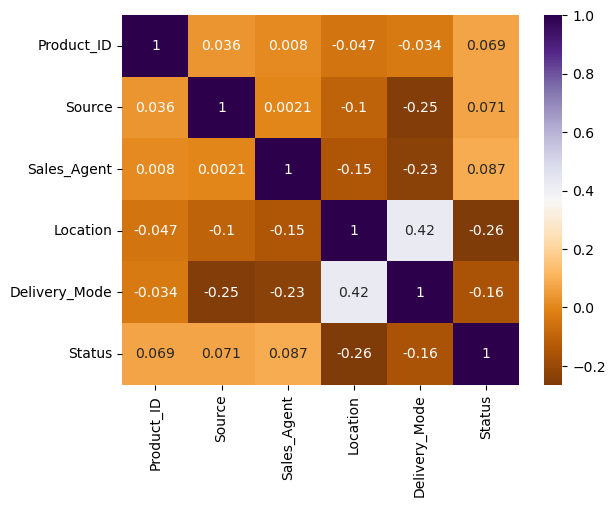

In [50]:
sns.heatmap(data.corr(),annot=True,cmap='PuOr')
plt.show()

* No highly correlated 

In [51]:
data.Delivery_Mode.unique()

array([4, 0, 2, 1, 3])

In [52]:
data.Sales_Agent.unique()

array([ 2,  1,  5,  6, 11,  9, 10,  7,  4,  3,  0,  8])

In [53]:
data.head(50)

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
0,18,2,2,6,4,1
1,18,2,1,6,4,1
2,18,2,1,6,4,1
3,18,2,1,6,4,1
4,18,2,1,6,4,1
5,18,2,1,6,4,1
6,18,2,1,6,4,1
7,18,2,1,6,4,1
8,18,2,1,6,4,1
9,18,2,1,6,4,1


array([[<Axes: title={'center': 'Product_ID'}>,
        <Axes: title={'center': 'Source'}>],
       [<Axes: title={'center': 'Sales_Agent'}>,
        <Axes: title={'center': 'Location'}>],
       [<Axes: title={'center': 'Delivery_Mode'}>,
        <Axes: title={'center': 'Status'}>]], dtype=object)

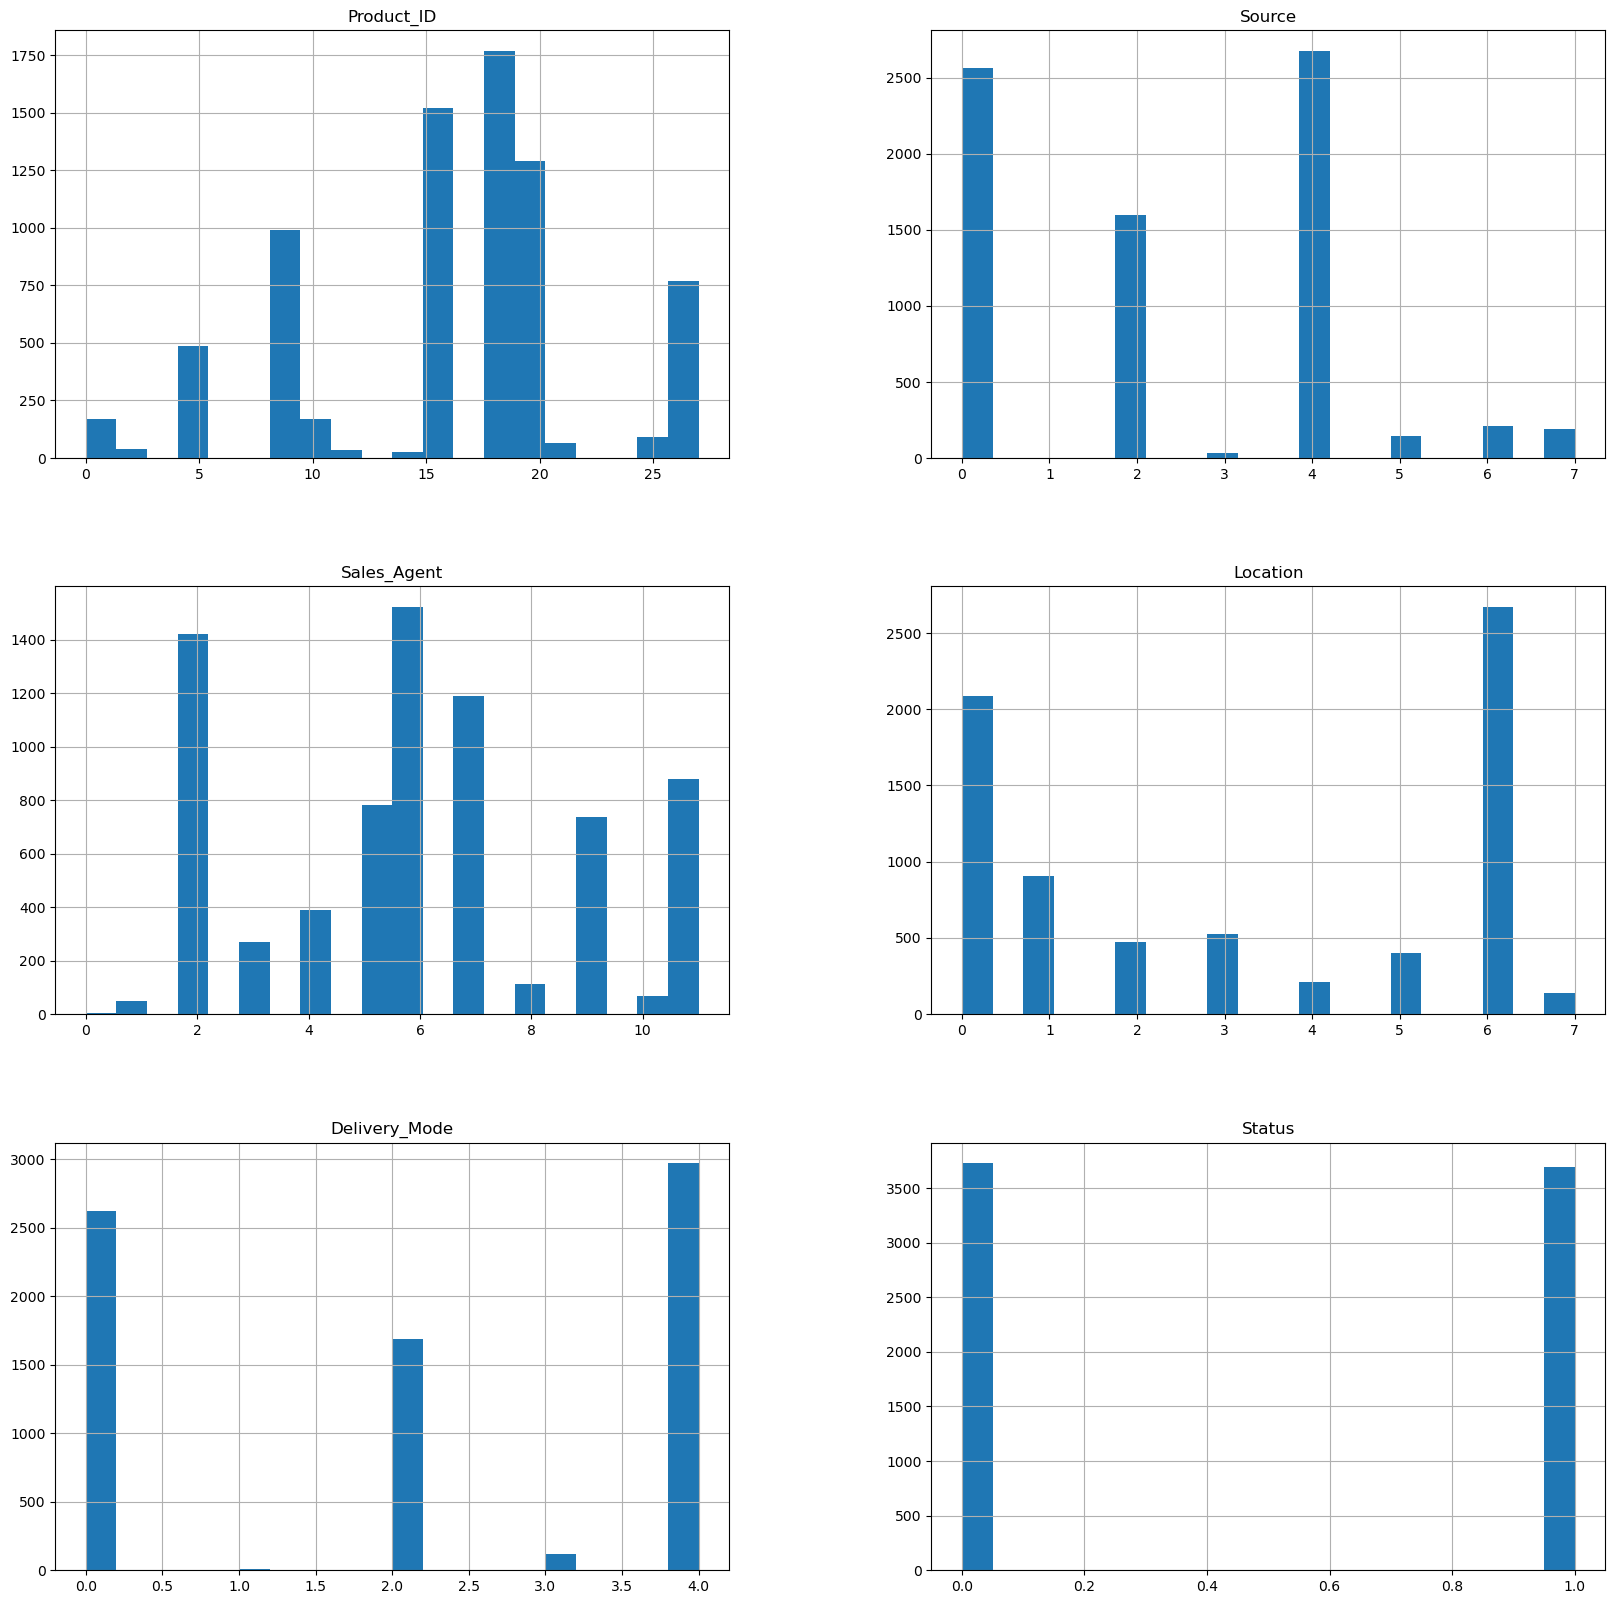

In [54]:
data.hist(bins=20,figsize=(20,20))


#### Saving Preprocess Data

In [55]:
data.to_csv("preprocess_data_sales_prcl_0019.csv")

In [56]:
df = pd.read_csv('preprocess_data_sales_prcl_0019.csv')
df.head()

,Unnamed: 0,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
0,0,18,2,2,6,4,1
1,1,18,2,1,6,4,1
2,2,18,2,1,6,4,1
3,3,18,2,1,6,4,1
4,4,18,2,1,6,4,1


In [57]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
0,18,2,2,6,4,1
1,18,2,1,6,4,1
2,18,2,1,6,4,1
3,18,2,1,6,4,1
4,18,2,1,6,4,1


Define Independent Variable and Dependent Variable

In [58]:
x = df.drop(columns=['Status'])
x.head()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode
0,18,2,2,6,4
1,18,2,1,6,4
2,18,2,1,6,4
3,18,2,1,6,4
4,18,2,1,6,4


In [59]:
y = df.Status

In [60]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Status, dtype: int64

In [61]:
y.value_counts()

Status
0    3731
1    3691
Name: count, dtype: int64

#### Spliting data into training and testing data

In [62]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [63]:
display(x_train.shape)
display(x_test.shape)
display(y_train.shape)
display(y_test.shape)

(5937, 5)

(1485, 5)

(5937,)

(1485,)

#### Model Training



### Logistic Regression

In [64]:
from sklearn.linear_model import LogisticRegression


model_lr = LogisticRegression(random_state=42)
model_lr.fit(x_train, y_train)


LogisticRegression(random_state=42)

[0 0 0 ... 1 1 0]
Accuracy Score: 0.6336700336700337

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.64      0.64       753
           1       0.63      0.62      0.63       732

    accuracy                           0.63      1485
   macro avg       0.63      0.63      0.63      1485
weighted avg       0.63      0.63      0.63      1485



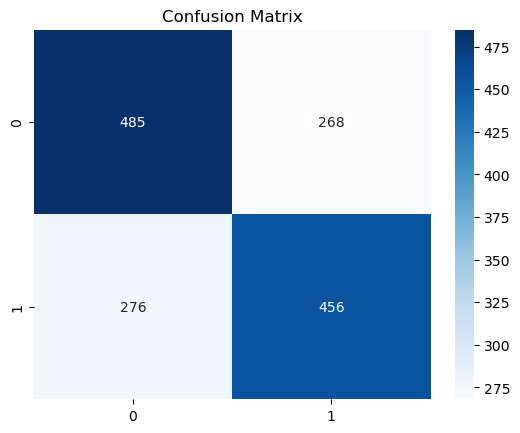

In [98]:
pred_lr = model_lr.predict(x_test)

print(pred_lr)



print("Accuracy Score:", accuracy_score(y_test, pred_lr))
print("\nClassification Report:\n", classification_report(y_test, pred_lr))


sns.heatmap(confusion_matrix(y_test, pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()



### Apply Standard scalar

applying standardScaler and helps the model learn better by scaling features, not by changing the expected output.

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [68]:
model_lr_scale = LogisticRegression(max_iter=1000)
model_lr_scale.fit(x_train_scaled, y_train)


lr_pred_scale = model_lr_scale.predict(x_test_scaled)


print("Accuracy:", accuracy_score(y_test, lr_pred_scale))
print(classification_report(y_test, lr_pred_scale))

Accuracy: 0.6336700336700337
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       753
           1       0.63      0.62      0.63       732

    accuracy                           0.63      1485
   macro avg       0.63      0.63      0.63      1485
weighted avg       0.63      0.63      0.63      1485



### KNN

In [69]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train_scaled, y_train)

pred_knn = model_knn.predict(x_test_scaled)


print("Accuracy:", accuracy_score(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

Accuracy: 0.6356902356902356
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       753
           1       0.63      0.63      0.63       732

    accuracy                           0.64      1485
   macro avg       0.64      0.64      0.64      1485
weighted avg       0.64      0.64      0.64      1485



### Applying Bagging on KNeighbours classifier

In [71]:

knn1 = KNeighborsClassifier(n_neighbors=3)


from sklearn.ensemble import BaggingClassifier
bagg = BaggingClassifier(base_estimator=knn1,n_estimators=50)


bagg.fit(x_train_scaled,y_train)


bagg_predict = bagg.predict(x_test_scaled)

In [72]:
bagg_accuracy = accuracy_score(y_test,bagg_predict)
print("Score after bagging:",bagg_accuracy*100)

Score after bagging: 64.37710437710437


In [73]:
error_rate = [] # Creating empty list
for i in range(2,11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_knn_predict = knn.predict(x_test)
    error_rate.append(np.mean(y_knn_predict != y_test))
print("Error rate:",error_rate)




Error rate: [0.3872053872053872, 0.35555555555555557, 0.37104377104377106, 0.3548821548821549, 0.3575757575757576, 0.3474747474747475, 0.3441077441077441, 0.3373737373737374, 0.35218855218855216]


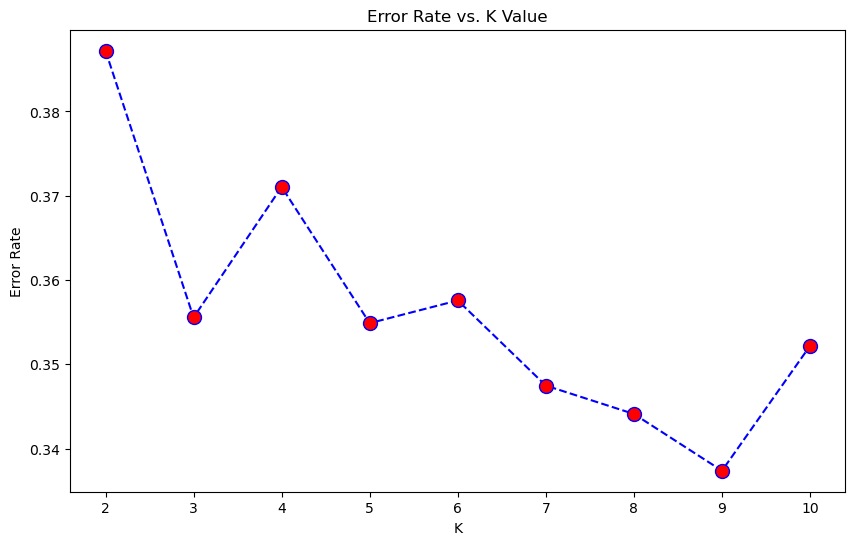

In [74]:

plt.figure(figsize=(10,6))
plt.plot(range(2,11),error_rate,color='blue', linestyle='dashed',marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

### Decision Tree

In [75]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42, max_depth=5)

model_dt.fit(x_train, y_train)

dt_test_pred = model_dt.predict(x_test)
dt_train_pred = model_dt.predict(x_train)



In [76]:
dtc_train_accuracy = accuracy_score(y_train,dt_train_pred)

print("Training accuracy of Decision tree classifier:",dtc_train_accuracy*100)
print("classification report of training:"'\n',classification_report(y_train,dt_train_pred))

Training accuracy of Decision tree classifier: 66.06029981472123
classification report of training:
               precision    recall  f1-score   support

           0       0.76      0.48      0.58      2978
           1       0.62      0.85      0.71      2959

    accuracy                           0.66      5937
   macro avg       0.69      0.66      0.65      5937
weighted avg       0.69      0.66      0.65      5937



In [103]:
dtc_test_accuracy = accuracy_score(y_test,dt_test_pred)

print("Testing accuracy of Decision tree classifier:",dtc_test_accuracy*100)
print("classification report of training:"'\n',classification_report(y_test,dt_test_pred))

Testing accuracy of Decision tree classifier: 65.65656565656566
classification report of training:
               precision    recall  f1-score   support

           0       0.75      0.49      0.59       753
           1       0.61      0.83      0.70       732

    accuracy                           0.66      1485
   macro avg       0.68      0.66      0.65      1485
weighted avg       0.68      0.66      0.65      1485



Model Performance is little greater than logistics regression 

In [78]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

x_train_sm, y_train_sm = sm.fit_resample(x_train, y_train)

display(f'old class distribution {np.bincount(y_train)}')
display(f'new class distribution {np.bincount(y_train_sm)}')


'old class distribution [2978 2959]'

'new class distribution [2978 2978]'

### Hyperparameter tuning ( GridSearchCV )

In [79]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), 
                       param_grid, cv=5, scoring='f1', n_jobs=-1)


dt_grid.fit(x_train_sm, y_train_sm)


best_dt = dt_grid.best_estimator_
print("Best Parameters Found:", dt_grid.best_params_)

Best Parameters Found: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [80]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_dt.predict(x_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print('Accuracy after tuned -->',accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.43      0.55       753
           1       0.60      0.87      0.71       732

    accuracy                           0.65      1485
   macro avg       0.69      0.65      0.63      1485
weighted avg       0.69      0.65      0.63      1485

[[324 429]
 [ 94 638]]
Accuracy after tuned --> 0.6478114478114478


Even after tuning model did not improve so the best model is model without tuning and with standard scalar dataset

In [81]:
import pandas as pd

importance = pd.Series(best_dt.feature_importances_, index=x_train.columns)
print(importance.sort_values(ascending=False))


Location         0.335252
Product_ID       0.307331
Sales_Agent      0.224165
Source           0.117534
Delivery_Mode    0.015718
dtype: float64


In [82]:
from sklearn.metrics import f1_score

train_pred = best_dt.predict(x_train_sm)
print("Train F1:", f1_score(y_train_sm, train_pred))
print("Test F1:", f1_score(y_test, y_pred))


Train F1: 0.7200656096227446
Test F1: 0.7092829349638687


No overfitting (gap of 0.05)

The model shows strong generalization ability, as the training and testing F1 scores are very close (0.72 vs 0.71), indicating minimal overfitting and stable performance on unseen data.

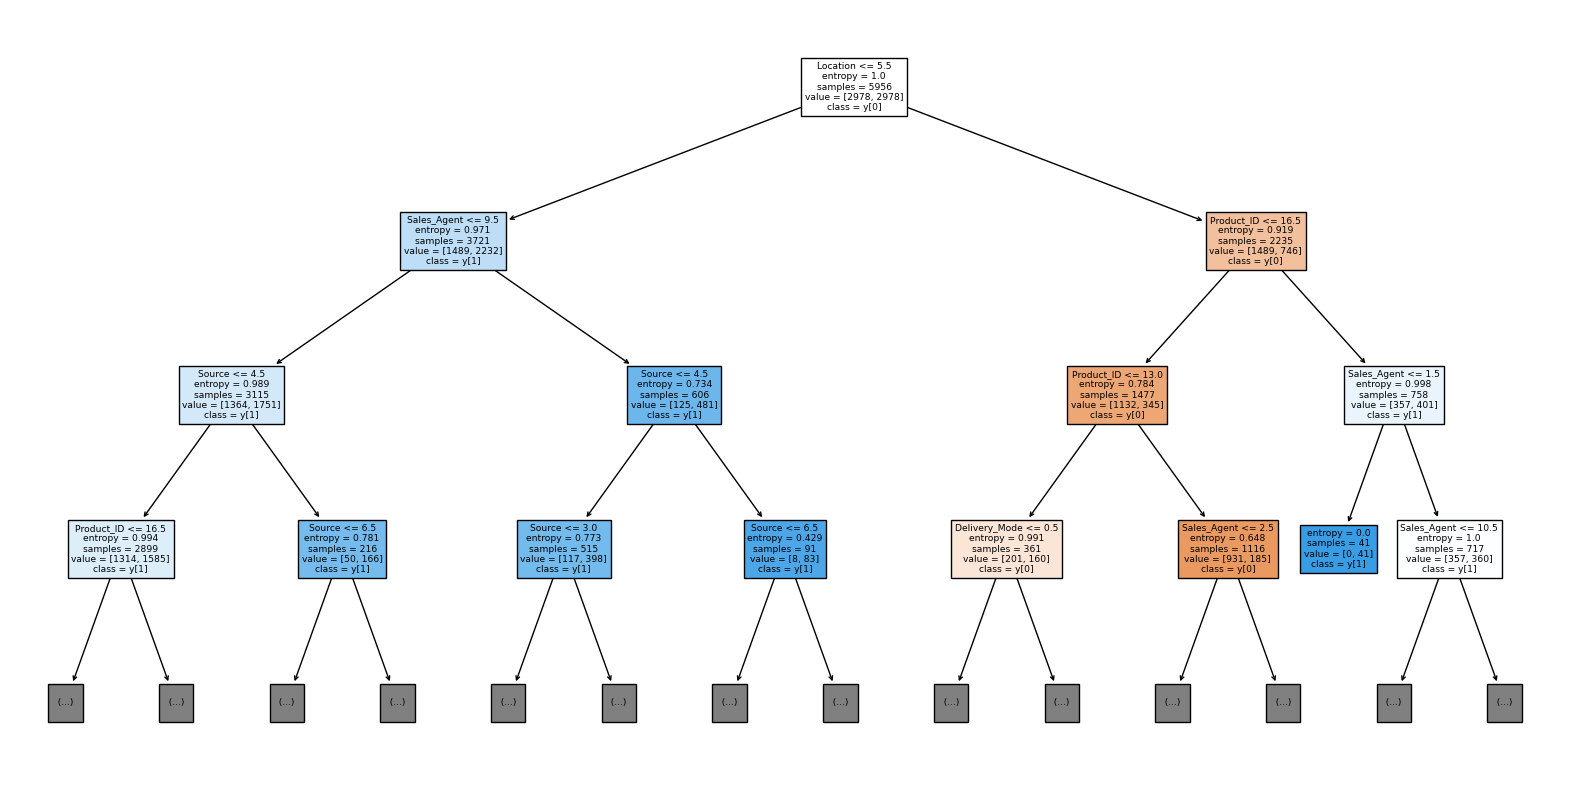

In [83]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(best_dt,max_depth=3, filled=True, feature_names=x_train_sm.columns, class_names=True)
plt.show()


In [84]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report

bag_clf = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(
        max_depth=best_dt.max_depth,
        min_samples_leaf=best_dt.min_samples_leaf,
        random_state=42
    ),
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bag_clf.fit(x_train_sm, y_train_sm)

y_pred_bag = bag_clf.predict(x_test)

print("Bagging Test F1:", f1_score(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag))


Bagging Test F1: 0.6991576413959085
              precision    recall  f1-score   support

           0       0.73      0.54      0.62       753
           1       0.62      0.79      0.70       732

    accuracy                           0.66      1485
   macro avg       0.68      0.67      0.66      1485
weighted avg       0.68      0.66      0.66      1485



In this case, variance reduction through bagging did not translate into better F1-score performance due to class imbalance effects introduced by SMOTE.

### Random Forest Model

In [85]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth= None,
    min_samples_leaf= 2,
    random_state= 42,
    n_jobs= -1
)

model_rf.fit(x_train_sm, y_train_sm)

y_pred_rf = model_rf.predict(x_test)

rf_f1 = f1_score(y_test, y_pred_rf)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Test F1:", rf_f1)
print("Random Forest Accuracy:", rf_acc)
print(classification_report(y_test, y_pred_rf))


Random Forest Test F1: 0.6567366283006093
Random Forest Accuracy: 0.6585858585858586
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       753
           1       0.65      0.66      0.66       732

    accuracy                           0.66      1485
   macro avg       0.66      0.66      0.66      1485
weighted avg       0.66      0.66      0.66      1485



In [86]:

param_grid_rf = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(x_train_sm, y_train_sm)

best_rf = rf_grid.best_estimator_
print("Best RF Parameters:", rf_grid.best_params_)


Best RF Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}


In [87]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

y_pred_rf = best_rf.predict(x_test)

print("Tuned RF Test F1:", f1_score(y_test, y_pred_rf))
print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Tuned RF Test F1: 0.6920103092783505
Tuned RF Accuracy: 0.6781144781144781
              precision    recall  f1-score   support

           0       0.71      0.62      0.66       753
           1       0.65      0.73      0.69       732

    accuracy                           0.68      1485
   macro avg       0.68      0.68      0.68      1485
weighted avg       0.68      0.68      0.68      1485



By Hyperparameter tuning accuracy is improve by 0.2%

so the accepted accuracy with tuned is taken which is 67%

### Gradient Boost Model

In [88]:
model_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_gb.fit(x_train_sm, y_train_sm)

y_pred_gb = model_gb.predict(x_test)

print("Gradient Boosting F1:", f1_score(y_test, y_pred_gb))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


Gradient Boosting F1: 0.7093023255813954
Gradient Boosting Accuracy: 0.696969696969697
              precision    recall  f1-score   support

           0       0.73      0.65      0.68       753
           1       0.67      0.75      0.71       732

    accuracy                           0.70      1485
   macro avg       0.70      0.70      0.70      1485
weighted avg       0.70      0.70      0.70      1485



tuning gradient boost

In [89]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

gb_grid.fit(x_train_sm, y_train_sm)

best_gb = gb_grid.best_estimator_
print("Best GB Parameters:", gb_grid.best_params_)


Best GB Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


Evaluate tuned GB

In [90]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

y_pred_gb = best_gb.predict(x_test)

print("Tuned GB F1:", f1_score(y_test, y_pred_gb))
print("Tuned GB Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


Tuned GB F1: 0.7069525666016894
Tuned GB Accuracy: 0.6962962962962963
              precision    recall  f1-score   support

           0       0.72      0.65      0.68       753
           1       0.67      0.74      0.71       732

    accuracy                           0.70      1485
   macro avg       0.70      0.70      0.70      1485
weighted avg       0.70      0.70      0.70      1485



In [91]:
from sklearn.neural_network import MLPClassifier


model_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42
)

model_mlp.fit(x_train_sm, y_train_sm)

y_pred_mlp = model_mlp.predict(x_test)

print("ANN F1:", f1_score(y_test, y_pred_mlp))
print("ANN Accuracy:", accuracy_score(y_test, y_pred_mlp))


ANN F1: 0.6975903614457831
ANN Accuracy: 0.661952861952862


### CatBoost Model

In [92]:
cat_idx = list(range(x_train.shape[1]))
display(cat_idx)

[0, 1, 2, 3, 4]

In [93]:
from catboost import CatBoostClassifier


cb = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=0
)

cb.fit(
    x_train,
    y_train,
    cat_features=cat_idx
)


In [94]:
y_pred_cb = cb.predict(x_test)

print("CatBoost F1:", f1_score(y_test, y_pred_cb))
print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cb))
print(classification_report(y_test, y_pred_cb))


CatBoost F1: 0.7107969151670951
CatBoost Accuracy: 0.696969696969697
              precision    recall  f1-score   support

           0       0.73      0.64      0.68       753
           1       0.67      0.76      0.71       732

    accuracy                           0.70      1485
   macro avg       0.70      0.70      0.70      1485
weighted avg       0.70      0.70      0.70      1485



### Compare accuracy of every model


In [107]:
# Only taking best score for model performance.



lr_accuracy = accuracy_score(y_test, pred_lr)
knn_accuracy = accuracy_score(y_test,bagg_predict)
dt_accuracy = accuracy_score(y_train,dt_train_pred)
bag_accuracy = accuracy_score(y_test, bag_clf.predict(x_test))
rf_accuracy = accuracy_score(y_test, best_rf.predict(x_test))
gb_accuracy = accuracy_score(y_test, best_gb.predict(x_test))
cb_accuracy = accuracy_score(y_test, cb.predict(x_test))


In [108]:
model_accuracies = {
    'Linear Regression' : lr_accuracy,
    'KNN' : knn_accuracy,
    'Decision Tree': dt_accuracy,
    'Bagging': bag_accuracy,
    'Random Forest': rf_accuracy,
    'Gradient Boosting': gb_accuracy,
    'CatBoost': cb_accuracy
}


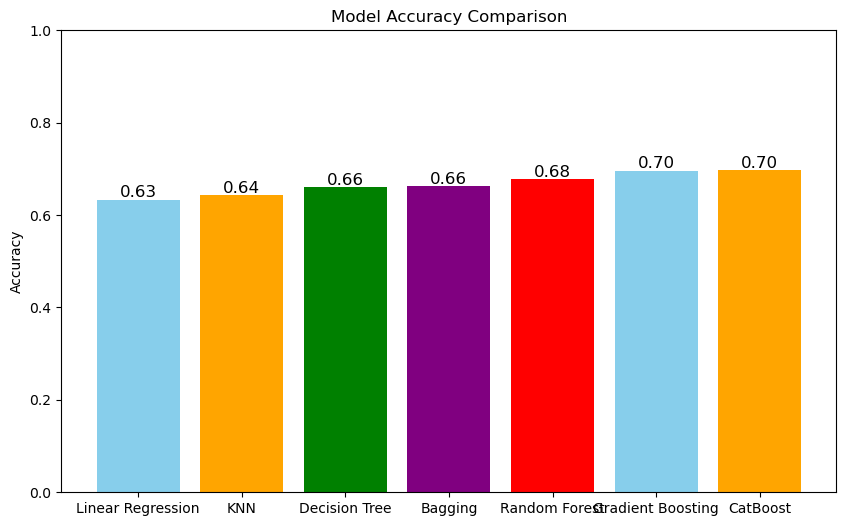

In [109]:
import matplotlib.pyplot as plt

models = list(model_accuracies.keys())
accuracy = list(model_accuracies.values())

plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracy, color=['skyblue','orange','green','purple','red'])

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.2f}', ha='center', fontsize=12)

plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()
